<a href="https://colab.research.google.com/github/hatamimatt/ClimateDataScience/blob/main/nex_gddp_cmip6_extremeRainfallUSSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STEP 1 — Install packages
# ============================================================

!pip install xarray dask h5netcdf s3fs cftime pandas numpy matplotlib rioxarray rasterio netcdf4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 32.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.


In [2]:
# ============================================================
# STEP 2 — Import libraries
# ============================================================

import s3fs
import xarray as xr
import rioxarray as rxr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path to the shared folder shortcut
# Change 'Colab_Project' to your actual folder name
path = "/content/drive/MyDrive/SE_Design_Storms"

Mounted at /content/drive


In [3]:
# ============================================================
# STEP 3 — Connect to NEX-GDDP-CMIP6 on AWS
# ============================================================

fs = s3fs.S3FileSystem(anon=True)

# Test connection
fs.ls("nex-gddp-cmip6/NEX-GDDP-CMIP6")[:5]

['nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-ESM1-5',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/BCC-CSM2-MR',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/CESM2',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/CESM2-WACCM']

In [4]:
# ============================================================
# STEP 4 — Project settings
# ============================================================

# Approximate Southeast U.S. bounding box
lat_min, lat_max = 24, 38
lon_min, lon_max = -94, -75

baseline_years = range(1981, 2011)
future_years = range(2071, 2101)

models = [
    "ACCESS-CM2",
    "CanESM5",
    "MIROC6",
    "MRI-ESM2-0",
    "GFDL-CM4"
]

scenarios = ["ssp245", "ssp585"]

variable = "pr"

threshold_files = {
    "10yr": "se10yr24ha.asc",
    "25yr": "se25yr24ha.asc",
    "50yr": "se50yr24ha.asc",
    "100yr": "se100yr24ha.asc"
}

os.makedirs("outputs", exist_ok=True)

In [5]:
# ============================================================
# STEP 5 — Find available model variant
# ============================================================

def find_variant(model, scenario):
    """
    Finds the variant folder for a model and scenario.
    Most commonly this is r1i1p1f1.
    """

    base = f"nex-gddp-cmip6/NEX-GDDP-CMIP6/{model}/{scenario}"

    try:
        folders = fs.ls(base)
    except:
        return None

    variants = [folder.split("/")[-1] for folder in folders]

    if "r1i1p1f1" in variants:
        return "r1i1p1f1"

    if len(variants) > 0:
        return variants[0]

    return None

In [6]:
# ============================================================
# STEP 6 — Get one latest file per year
# ============================================================

def get_latest_files_by_year(model, scenario, variant, variable, years):
    """
    NEX-GDDP sometimes has multiple versions for the same year.
    This function keeps only one file per year, preferring v1.2, then v1.1.
    """

    folder = f"nex-gddp-cmip6/NEX-GDDP-CMIP6/{model}/{scenario}/{variant}/{variable}"

    try:
        all_files = fs.glob(folder + "/*.nc")
    except:
        return []

    selected_files = []

    for year in years:
        year_files = [file for file in all_files if f"_{year}" in file]

        if len(year_files) == 0:
            continue

        v12_files = [file for file in year_files if "_v1.2.nc" in file]
        v11_files = [file for file in year_files if "_v1.1.nc" in file]

        if len(v12_files) > 0:
            chosen_file = v12_files[0]
        elif len(v11_files) > 0:
            chosen_file = v11_files[0]
        else:
            chosen_file = year_files[0]

        selected_files.append("s3://" + chosen_file)

    return selected_files

In [7]:
# ============================================================
# STEP 7 — Open precipitation and subset Southeast
# ============================================================

def open_precip_for_southeast(files):
    """
    Opens daily precipitation files, converts to mm/day,
    converts longitude to -180 to 180, and subsets to Southeast U.S.
    """

    ds = xr.open_mfdataset(
        files,
        engine="h5netcdf",
        combine="by_coords",
        chunks={"time": 90},
        backend_kwargs={"storage_options": {"anon": True}}
    )

    pr = ds["pr"] * 86400
    pr.attrs["units"] = "mm/day"

    pr = pr.assign_coords(
        lon=((pr.lon + 180) % 360) - 180
    ).sortby("lon")

    pr_se = pr.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )

    return pr_se

In [8]:
# ============================================================
# STEP 8 — Load Atlas 14 threshold and align to climate grid
# ============================================================

def load_atlas_threshold_on_grid(atlas_file, target_grid):
    """
    Loads an Atlas 14 ASCII grid and interpolates it to the NEX-GDDP grid.

    NOAA Atlas ASCII values appear to be stored as thousandths of inches:
    raw / 1000 = inches
    inches * 25.4 = mm
    """

    atlas = rxr.open_rasterio(atlas_file, masked=True)
    atlas = atlas.squeeze("band", drop=True)
    atlas = atlas.rename({"x": "lon", "y": "lat"})

    atlas_mm = (atlas / 1000) * 25.4
    atlas_mm.attrs["units"] = "mm"

    atlas_on_grid = atlas_mm.interp(
        lat=target_grid.lat,
        lon=target_grid.lon
    )

    return atlas_on_grid

In [9]:
# ============================================================
# STEP 9 — Compute design-storm exceedance
# ============================================================

def compute_design_storm_exceedance(hist_pr, future_pr, atlas_threshold):
    """
    Uses a simple bias-correction factor based on historical annual maxima,
    then calculates historical and future exceedance frequency.
    """

    # Historical annual maximum daily precipitation
    hist_annual_max = hist_pr.resample(time="YS").max()

    # Approximate 10-year-like event from model historical annual maxima
    model_hist_10yr_like = hist_annual_max.quantile(0.90, dim="time").compute()

    # Scale model rainfall so its historical extreme magnitude matches Atlas threshold
    correction_factor = atlas_threshold / model_hist_10yr_like

    # Avoid extreme correction values
    correction_factor = correction_factor.clip(min=0.5, max=5)

    hist_pr_corrected = hist_pr * correction_factor
    future_pr_corrected = future_pr * correction_factor

    hist_exceed = hist_pr_corrected > atlas_threshold
    future_exceed = future_pr_corrected > atlas_threshold

    hist_annual_exceed = hist_exceed.resample(time="YS").sum()
    future_annual_exceed = future_exceed.resample(time="YS").sum()

    hist_mean = hist_annual_exceed.mean(dim="time")
    future_mean = future_annual_exceed.mean(dim="time")

    change = future_mean - hist_mean
    ratio = future_mean / hist_mean.where(hist_mean > 0)

    return hist_mean, future_mean, change, ratio

In [10]:
# ============================================================
# STEP 10 — Test one model, one scenario, one threshold first
# ============================================================

test_model = "ACCESS-CM2"
test_scenario = "ssp245"
test_threshold_name = "10yr"
test_atlas_file = threshold_files[test_threshold_name]

hist_variant = find_variant(test_model, "historical")
future_variant = find_variant(test_model, test_scenario)

print("Historical variant:", hist_variant)
print("Future variant:", future_variant)

Historical variant: r1i1p1f1
Future variant: r1i1p1f1


In [11]:
hist_files = get_latest_files_by_year(
    model=test_model,
    scenario="historical",
    variant=hist_variant,
    variable=variable,
    years=baseline_years
)

future_files = get_latest_files_by_year(
    model=test_model,
    scenario=test_scenario,
    variant=future_variant,
    variable=variable,
    years=future_years
)

print("Historical files:", len(hist_files))
print("Future files:", len(future_files))

Historical files: 30
Future files: 30


In [12]:
hist_pr = open_precip_for_southeast(hist_files)
future_pr = open_precip_for_southeast(future_files)

hist_pr

<xarray.DataArray 'pr' (time: 10957, lat: 56, lon: 76)> Size: 187MB
dask.array<getitem, shape=(10957, 56, 76), dtype=float32, chunksize=(90, 56, 76), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 88kB 1981-01-01T12:00:00 ... 2010-12-31T12...
  * lat      (lat) float64 448B 24.12 24.38 24.62 24.88 ... 37.38 37.62 37.88
  * lon      (lon) float64 608B -93.88 -93.62 -93.38 ... -75.62 -75.38 -75.12
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          mm/day
    comment:        includes both liquid and solid phases
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [14]:
import os

atlas_folder = "/content/drive/MyDrive/SE_Design_Storms"

threshold_files = {
    "10yr":  f"{atlas_folder}/se10yr24ha/se10yr24ha.asc",
    "25yr":  f"{atlas_folder}/se25yr24ha/se25yr24ha.asc",
    "50yr":  f"{atlas_folder}/se50yr24ha/se50yr24ha.asc",
    "100yr": f"{atlas_folder}/se100yr24ha/se100yr24ha.asc"
}

for name, path in threshold_files.items():
    print(name, os.path.exists(path), path)

10yr True /content/drive/MyDrive/SE_Design_Storms/se10yr24ha/se10yr24ha.asc
25yr True /content/drive/MyDrive/SE_Design_Storms/se25yr24ha/se25yr24ha.asc
50yr True /content/drive/MyDrive/SE_Design_Storms/se50yr24ha/se50yr24ha.asc
100yr True /content/drive/MyDrive/SE_Design_Storms/se100yr24ha/se100yr24ha.asc


In [15]:
def load_atlas_threshold_on_grid(atlas_file, target_grid):
    """
    Loads Atlas 14 ASCII grid, converts to mm,
    and interpolates it to the NEX-GDDP climate grid.
    """

    atlas = rxr.open_rasterio(atlas_file, masked=True)
    atlas = atlas.squeeze("band", drop=True)
    atlas = atlas.rename({"x": "lon", "y": "lat"})

    # Atlas values are stored as thousandths of inches
    atlas_mm = (atlas / 1000) * 25.4
    atlas_mm.attrs["units"] = "mm"

    atlas_on_grid = atlas_mm.interp(
        lat=target_grid.lat,
        lon=target_grid.lon
    )

    return atlas_on_grid

In [16]:
atlas_threshold = load_atlas_threshold_on_grid(
    atlas_file=threshold_files["10yr"],
    target_grid=hist_pr
)

print("Atlas 10-year 24-hour min mm:", float(atlas_threshold.min().compute()))
print("Atlas 10-year 24-hour max mm:", float(atlas_threshold.max().compute()))

Atlas 10-year 24-hour min mm: 122.02048415811674
Atlas 10-year 24-hour max mm: 239.7503594604561


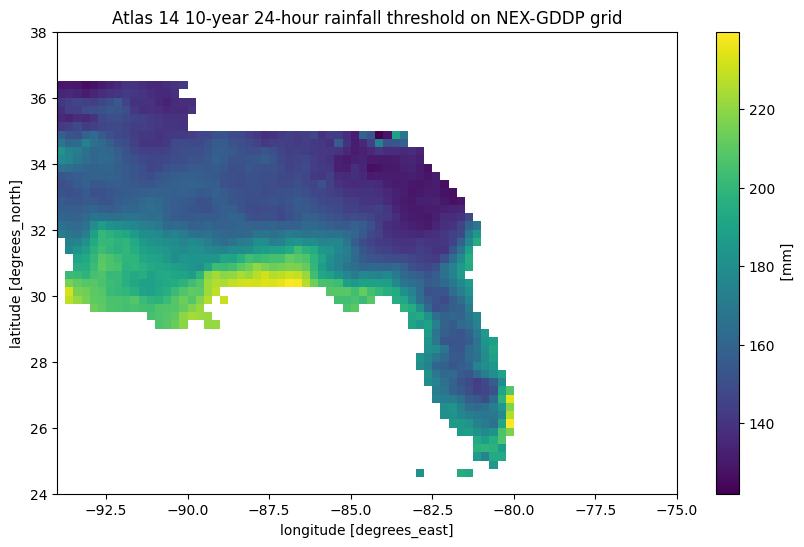

In [17]:
plt.figure(figsize=(10, 6))
atlas_threshold.plot()
plt.title("Atlas 14 10-year 24-hour rainfall threshold on NEX-GDDP grid")
plt.show()

In [18]:
def compute_design_storm_exceedance(hist_pr, future_pr, atlas_threshold):
    """
    Bias-corrects model rainfall using historical annual maxima,
    then calculates design-storm exceedance frequency.
    """

    hist_annual_max = hist_pr.resample(time="YS").max()

    model_hist_10yr_like = hist_annual_max.quantile(0.90, dim="time").compute()

    correction_factor = atlas_threshold / model_hist_10yr_like
    correction_factor = correction_factor.clip(min=0.5, max=5)

    hist_pr_corrected = hist_pr * correction_factor
    future_pr_corrected = future_pr * correction_factor

    hist_exceed = hist_pr_corrected > atlas_threshold
    future_exceed = future_pr_corrected > atlas_threshold

    hist_annual_exceed = hist_exceed.resample(time="YS").sum()
    future_annual_exceed = future_exceed.resample(time="YS").sum()

    hist_mean = hist_annual_exceed.mean(dim="time")
    future_mean = future_annual_exceed.mean(dim="time")

    change = future_mean - hist_mean
    ratio = future_mean / hist_mean.where(hist_mean > 0)

    return hist_mean, future_mean, change, ratio

In [19]:
hist_mean, future_mean, change, ratio = compute_design_storm_exceedance(
    hist_pr=hist_pr,
    future_pr=future_pr,
    atlas_threshold=atlas_threshold
)

print("Historical mean exceedance:", float(hist_mean.mean().compute()))
print("Future mean exceedance:", float(future_mean.mean().compute()))
print("Change:", float(change.mean().compute()))

Historical mean exceedance: 0.03166510025062656
Future mean exceedance: 0.10238878446115288
Change: 0.07072368421052631


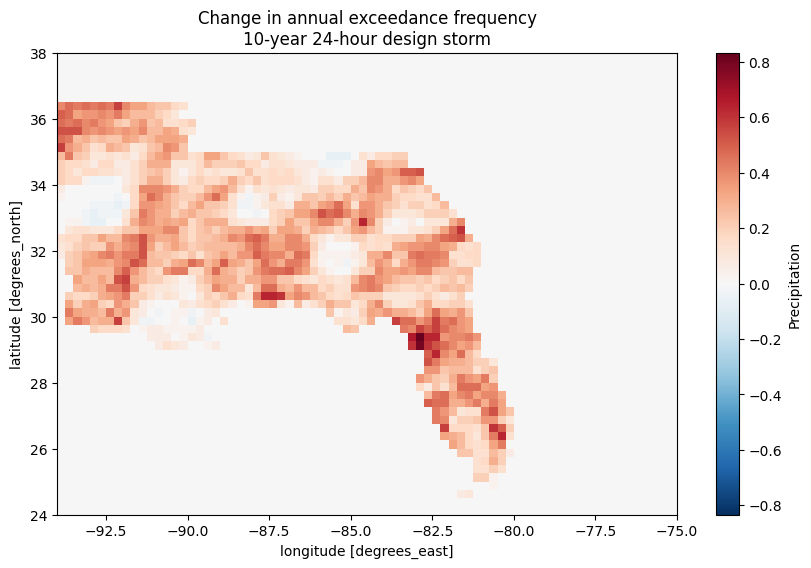

In [20]:
plt.figure(figsize=(10, 6))
change.plot(cmap="RdBu_r")
plt.title("Change in annual exceedance frequency\n10-year 24-hour design storm")
plt.show()

In [21]:
rolling = future_pr.resample(time="D").max().rolling(time=5).sum()

compound = rolling > (2 * atlas_threshold)

compound_events = compound.resample(time="YS").sum().mean()

print("Compound events per year:", float(compound_events.mean().compute()))

ValueError: Moving window (=5) must between 1 and 4, inclusive

In [ ]:
spatial_extent = (future_pr > atlas_threshold).mean(dim=["lat", "lon"])

regional_events = spatial_extent > 0.2

regional_event_count = regional_events.resample(time="YS").sum().mean()

print("Regional events per year:", float(regional_event_count.compute()))